# Importation des bibliothèques importantes : 

In [1]:
import datetime
import lightgbm as lgb
import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import plotly
import pandas as pd
from plotly.offline import init_notebook_mode
init_notebook_mode(connected=True)
import plotly.express as px


import scipy
from scipy.stats import normaltest
import seaborn as sns
import sklearn
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import cross_validate, train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error,  mean_absolute_percentage_error, r2_score
#from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn import linear_model

from sklearn.svm import SVR, LinearSVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
import sys

import time
#%matplotlib inline

import warnings

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)

# Versions
print('Version des librairies utilisées :')

print('NumPy                 : ' + np.version.full_version)
print('Pandas                : ' + pd.__version__)
print('Python                : ' + sys.version)
print('Plotly                : ' + plotly.__version__)
#print('Matplotlib            : ' + mpl.__version__)
print('Scipy                 : '+ scipy.__version__)
print('Seaborn               : ' + sns.__version__)
print('Sklearn               : ' + sklearn.__version__)
#print('jyquickhelper         : ' + jyquickhelper.__version__)

Version des librairies utilisées :
NumPy                 : 1.21.5
Pandas                : 1.4.2
Python                : 3.9.12 (main, Apr  4 2022, 05:22:27) [MSC v.1916 64 bit (AMD64)]
Plotly                : 5.6.0
Scipy                 : 1.7.3
Seaborn               : 0.11.2
Sklearn               : 1.3.0


# Importation des données 

In [2]:
#Chargement des données nettoyées
data=pd.read_csv('building_energy_propre.csv')

In [3]:
data.head()

,Unnamed: 0,BuildingType,PrimaryPropertyType,PropertyName,Neighborhood,LargestPropertyUseType,SecondLargestPropertyUseType,ThirdLargestPropertyUseType,BuildingAge,ENERGYSTARScore,SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),RateParking,RateBuilding,RatePerFloors,RatePerBuildings,RateLargestPropertyUseType,RateSecondLargestPropertyUseType,RateThirdLargestPropertyUseType,NumberOfAllUseTypes,haversine_distance,TotalGHGEmissionsLog,SiteEnergyUse(kBtu)Log
0,0,NonResidential,Hotel_and_catering,Mayflower park hotel,DOWNTOWN,Hotel_and_catering,no use,no use,89,60.0,1.0,1.0,1.0,0.0000,1.0000,7369.5000,88434.0,1.0000,0.0000,0.0000,1,0.804213,2.399639,6.858920
1,1,NonResidential,Hotel_and_catering,Paramount Hotel,DOWNTOWN,Hotel_and_catering,Parking,Hotel_and_catering,20,61.0,0.0,1.0,1.0,0.1455,0.8545,9415.0909,103566.0,0.8099,0.1455,0.0446,3,0.788419,2.472552,6.923655
2,2,NonResidential,Hotel_and_catering,5673-The Westin Seattle,DOWNTOWN,Hotel_and_catering,no use,no use,47,43.0,1.0,1.0,1.0,0.2057,0.7943,23319.7561,956110.0,0.7912,0.0000,0.0000,1,0.973609,3.320204,7.860859
3,3,NonResidential,Hotel_and_catering,HOTEL MAX,DOWNTOWN,Hotel_and_catering,no use,no use,90,56.0,1.0,1.0,1.0,0.0000,1.0000,6132.0000,61320.0,1.0000,0.0000,0.0000,1,0.946869,2.458532,6.832163
4,4,NonResidential,Hotel_and_catering,WARWICK SEATTLE HOTEL (ID8),DOWNTOWN,Hotel_and_catering,Parking,Leisure,36,75.0,0.0,1.0,1.0,0.3531,0.6469,9754.4444,175580.0,0.7031,0.3873,0.0000,3,1.052598,2.704159,7.151450


In [4]:
if 'Unnamed: 0' in data.columns:
    data.drop('Unnamed: 0', axis=1, inplace=True)

In [5]:
#copie pour suivi et comparaison
data_initial= data.copy()

# Preprocessing

In [6]:
seed= 42


In [7]:
data.drop("PropertyName" , axis = 1, inplace= True)


## Dataset pour le choix de modèle

In [8]:
## Suppression de la colonne 'ENERGYSTARScore' pour la modélisation

model_data = data.drop(columns = "ENERGYSTARScore")



Les variables numériques et catégorielles doivent etre standardisées et encodées. Pour ce faire nous devons les identifier.


In [9]:
model_data.dropna(how = 'any', inplace=True)


In [10]:
## Identification des variables catégorielles et numériques

categorical = model_data.select_dtypes(exclude = "number").columns.tolist()

numerical = model_data.select_dtypes(include = "number").columns.tolist()

# Suppression des cibles dans les variables numériques
numerical.remove("SiteEnergyUse(kBtu)Log")
numerical.remove("TotalGHGEmissionsLog")

In [11]:
categorical

['BuildingType',
 'PrimaryPropertyType',
 'Neighborhood',
 'LargestPropertyUseType',
 'SecondLargestPropertyUseType',
 'ThirdLargestPropertyUseType']

In [12]:
numerical

['BuildingAge',
 'SteamUse(kBtu)',
 'Electricity(kBtu)',
 'NaturalGas(kBtu)',
 'RateParking',
 'RateBuilding',
 'RatePerFloors',
 'RatePerBuildings',
 'RateLargestPropertyUseType',
 'RateSecondLargestPropertyUseType',
 'RateThirdLargestPropertyUseType',
 'NumberOfAllUseTypes',
 'haversine_distance']

## Séparation en train et test set

In [13]:
#Target consommation totale en énergie
X_Site_log = model_data.drop(columns = ["SiteEnergyUse(kBtu)Log","TotalGHGEmissionsLog"])
y_Site_log = model_data["SiteEnergyUse(kBtu)Log"]

# Séparation en train et test pour la consommation d'énergie

X_site_train, X_site_test, y_site_train, y_site_test = train_test_split(X_Site_log, y_Site_log, test_size=0.2, random_state=seed)

#Target émissions de Co2
X_Co2_log = model_data.drop(columns = ["TotalGHGEmissionsLog", "SiteEnergyUse(kBtu)Log"])
y_Co2_log = model_data["TotalGHGEmissionsLog"]

# Séparation en train et test pour les émissions de CO2

X_Co2_train, X_Co2_test, y_Co2_train, y_Co2_test = train_test_split(X_Co2_log, y_Co2_log, test_size=0.2, random_state=seed)
X_Co2_train

,BuildingType,PrimaryPropertyType,Neighborhood,LargestPropertyUseType,SecondLargestPropertyUseType,ThirdLargestPropertyUseType,BuildingAge,SteamUse(kBtu),Electricity(kBtu),NaturalGas(kBtu),RateParking,RateBuilding,RatePerFloors,RatePerBuildings,RateLargestPropertyUseType,RateSecondLargestPropertyUseType,RateThirdLargestPropertyUseType,NumberOfAllUseTypes,haversine_distance
2881,Multifamily LR (1-4),Residential,EAST,Residential,no use,no use,85,0.0,1.0,0.0,0.0000,1.0000,8107.5000,32430.0,1.0000,0.0000,0.0000,1,1.896294
1114,NonResidential,Education,NORTHWEST,Education,no use,no use,94,0.0,1.0,1.0,0.0000,1.0000,9606.6667,28820.0,1.1721,0.0000,0.0000,1,9.115632
678,Multifamily MR (5-9),Residential,EAST,Residential,Parking,no use,25,0.0,1.0,1.0,0.0000,1.0000,18559.2500,148474.0,0.4340,0.1010,0.0000,2,0.757436
2749,Multifamily LR (1-4),Residential,DOWNTOWN,Residential,Parking,no use,113,0.0,1.0,0.0,0.0000,1.0000,9200.0000,27600.0,0.6811,0.0000,0.0000,2,0.688941
2623,Multifamily LR (1-4),Residential,LAKE UNION,Residential,no use,no use,91,0.0,1.0,1.0,0.0000,1.0000,9395.6667,28187.0,1.0000,0.0000,0.0000,1,6.129186
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1095,Multifamily MR (5-9),Residential,LAKE UNION,Residential,no use,no use,8,0.0,1.0,1.0,0.0000,1.0000,27554.1667,165325.0,0.5099,0.0000,0.0000,1,4.577864
1130,NonResidential,Industrial,GREATER DUWAMISH,Industrial,no use,no use,47,0.0,1.0,0.0,0.0000,1.0000,20500.0000,20500.0,1.0432,0.0000,0.0000,1,6.125854
1294,Multifamily HR (10+),Residential,DOWNTOWN,Residential,Parking,Office,16,0.0,1.0,1.0,0.2274,0.7726,44869.1071,1256335.0,0.7484,0.2274,0.0242,4,0.462866
860,NonResidential,Commercial,NORTHEAST,Commercial,Other,no use,60,0.0,1.0,1.0,0.0000,1.0000,27142.0000,54284.0,0.9724,0.0350,0.0000,2,6.727337


In [15]:


print("Entrainement pour consommation d'électrité:  {} lignes,\n Test: {} lignes.\n".format(X_site_train.shape[0],X_site_test.shape[0]))

Entrainement pour consommation d'électrité:  2693 lignes,
 Test: 674 lignes.



## Standardisation et encodage pour les données de tests et d'entrainements


*Target Encoding* :

>Le Target Encoder permet d'encoder les variables catégorielles en utilisant la moyennede la cible dans chaque catégorie.

>Il calcule la probabilité que chaque cible se produise pour chaque groupe spécifique des variables catégorielles.


*Robust scaler* :

>Mise à l'échelle des données à l'aide de statistiques robustes aux valeurs aberrantes.

>Ce Scaler supprime la médiane et met à l'échelle les données en fonction de l'écart Interquartile).

>L'IQR est l'écart entre le 1er quartile (25e quantile) et le 3e quartile (75e quantile).

In [16]:
from category_encoders import TargetEncoder
from sklearn.preprocessing import RobustScaler
# Création de l'encodeur TargetEncoder et du scaler RobustScaler

encoder = TargetEncoder()
scaler = RobustScaler()

## Encodage :

In [17]:
# Encodage des variables catégorielles et mise à l'échelle des variables numériques pour les données d'entraînement
X_site_train[categorical] = encoder.fit_transform(X_site_train[categorical], y_site_train)

# Encodage des variables catégorielles pour les données de test (en utilisant fit_transform sur les données d'entraînement)
X_site_test[categorical] = encoder.transform(X_site_test[categorical])


## Standarisation :

In [18]:
# Mise à l'échelle des variables numériques pour les données d'entraînement
X_site_train[numerical] = scaler.fit_transform(X_site_train[numerical])

# Mise à l'échelle des variables numériques pour les données de test
X_site_test[numerical] = scaler.transform(X_site_test[numerical])


# Modèles pour la consommation d'énergie : 


## Baseline

In [19]:
#timeit pour mesurer le temps d'exécution et suivre la performance 
def timed(f):
    
    def timed(*args, **kw):

        ts = time.time()
        result = f(*args, **kw)
        te = time.time()

        print (f"Durée d'exécution de {f.__name__}: {te-ts}s")
        return result

    return timed




In [20]:

@timed
def regression(model,name,X,y):
    metrics = ['neg_mean_absolute_error', 'neg_mean_squared_error', 'r2']
    score = cross_validate(model,X,y,cv=10, scoring = metrics, return_train_score = True)
   # Calcul des métriques et création du dictionnaire avec les résultats 
    dico = {
        'modèle ': [name],
        'Fit time': [score['fit_time'].mean()],
        'Durée': [score['score_time'].mean()],
        'Test R2': [score['test_r2'].mean()],
        'Train R2': [score['train_r2'].mean()],
        'Test RMSE': [np.sqrt(- (score['train_neg_mean_squared_error'].mean()))],
        'Test MAE': [- (score['train_neg_mean_absolute_error'].mean())],
        'Train RMSE': [np.sqrt(- (score['train_neg_mean_squared_error'].mean()))],
        'Train MAE': [- (score['train_neg_mean_absolute_error'].mean())]
         }
        
   # Conversion en DataFrame pour une présentation lisible

    df_dico = pd.DataFrame(dico)
    return df_dico

In [21]:
from sklearn.dummy import DummyRegressor
@timed
def compare_resultat(X_train,y_train):
    resultats = pd.DataFrame()
    model =[]
  # Modèles à tester
    model.append(('dummy_regression', DummyRegressor(strategy='mean')))
    model.append(('linear_regression', linear_model.LinearRegression()))
    model.append(('elastic net', linear_model.ElasticNet(random_state=seed)))
    model.append(('random_forest', RandomForestRegressor(random_state=seed)))
    model.append(('svr', SVR()))
    model.append(('LGBM', lgb.LGBMRegressor()))
       
    for name, mod in model: 
        res = regression(mod, name, X_train, y_train)
        resultats = pd.concat([resultats,res], ignore_index=True)
    return resultats.style.hide_index()







In [22]:
baseline_SEU = compare_resultat(X_site_train, y_site_train)
baseline_SEU

Durée d'exécution de regression: 0.08858704566955566s
Durée d'exécution de regression: 0.2933499813079834s
Durée d'exécution de regression: 0.1405947208404541s
Durée d'exécution de regression: 94.2890796661377s
Durée d'exécution de regression: 11.673316955566406s
Durée d'exécution de regression: 2.3681986331939697s
Durée d'exécution de compare_resultat: 110.62781977653503s


modèle,Fit time,Durée,Test R2,Train R2,Test RMSE,Test MAE,Train RMSE,Train MAE
dummy_regression,0.002820,0.002584,-0.007339,0.000000,0.675619,0.417062,0.675619,0.417062
linear_regression,0.017463,0.007745,0.529263,0.536462,0.460161,0.265328,0.460161,0.265328
elastic net,0.003124,0.007811,0.098852,0.087953,0.645412,0.387245,0.645412,0.387245
random_forest,9.317015,0.028284,0.703367,0.954727,0.143787,0.074782,0.143787,0.074782
svr,0.394819,0.087738,0.462926,0.402597,0.522617,0.218255,0.522617,0.218255
LGBM,0.209456,0.006574,0.518757,0.820143,0.286567,0.143590,0.286567,0.143590


>Random Forest semble être le meilleur modèle pour prédire la consommation totale d'énergie, avec un Test R² élevé (0.703) et des erreurs faibles (RMSE et MAE faibles).

>Linear Regression et LGBM ont également des performances correctes, mais ne sont pas aussi performants que Random Forest.

>Elastic Net présente des performances médiocres avec un faible Test R² et des erreurs relativement élevées. Il semble moins adapté pour cette tâche.

>SVR présente des résultats moyens, mais moins bons que Random Forest et LGBM.

>Linear Regression et Elastic Net sont les plus rapides, tandis que Random Forest et LGBM prennent plus de temps mais offrent des performances significativement meilleures.

## Tuning des paramètres :

In [23]:
#On met en place une recherche de grille (GridSearchCV) afin d'optimiser les hyperparamètres des modèles.
@timed
def gridCV(model, parameters,X_train,y_train, cv):
    model_grid= GridSearchCV(estimator = model,
                        param_grid = parameters,
                        scoring='neg_root_mean_squared_error',
                        cv=cv,
                        return_train_score = True
                          )
    model_grid.fit(X_train,y_train)
    return model_grid


@timed
def resultats_grid(model_grid, name,X_train, y_train):
    #Récupération des paramètres de la grille. 
    cv_grid = pd.DataFrame(model_grid.cv_results_)
    
    y_pred = model_grid.predict(X_train)
    rmse= np.sqrt(sklearn.metrics.mean_squared_error(y_train, y_pred))
    #creation d'un dataframe des résultats
    results = {
        'modèle': [name],
        'Fit time': [cv_grid['mean_fit_time'].mean()],
        'Score time': [cv_grid['mean_score_time'].mean()],
        #'Best score RMSE': [-(model_grid.best_score_)],
        'Mean train score RMSE': [-(cv_grid["mean_train_score"].mean())],
        'Mean test score RMSE' : [-(cv_grid["mean_test_score"].mean())],
        'Best estimator': [model_grid.best_params_],
        'RMSE best estimator':[rmse]
         }
    df_resultats = pd.DataFrame(results)

    return df_resultats

### Elastic Net 

In [24]:
El_parameters ={
    'alpha': np.arange(0.001,10, 0.1),
    'l1_ratio' : np.arange(0.0, 1, 0.1)#L1 ratio =1 équivaut à un Lasso, 0 à un Ridge
            }


In [25]:
El_grid = gridCV(linear_model.ElasticNet(), El_parameters, X_site_train, y_site_train,5)


Durée d'exécution de gridCV: 87.18694281578064s


In [26]:
resultat_tunning = resultats_grid(El_grid, "ElasticNet",X_site_train, y_site_train)
resultat_tunning

Durée d'exécution de resultats_grid: 0.011475086212158203s


,modèle,Fit time,Score time,Mean train score RMSE,Mean test score RMSE,Best estimator,RMSE best estimator
0,ElasticNet,0.010632,0.002943,0.658926,0.655623,"{'alpha': 0.001, 'l1_ratio': 0.9}",0.461616


Le RMSE du meilleur modèle (0.461616) est assez bon et inférieur à certains autres modèles (comme ElasticNet dans le premier cas), ce qui montre que gridsearch a bien optimisé les hyperparamètres pour cette tâche spécifique.

Le temps d'ajustement est relativement court

Cela montre que ElasticNet avec cette configuration pourrait être un bon choix parmi les modèles testés.

### Random Forests 

In [28]:
random_parameters = {
             'max_features' : ['sqrt', 'log2', 'auto'],#nombre max de features prises en compte pour diviser un nœud
             'max_depth': [5, 15, 25, 50],#nombre maximum de niveaux dans chaque arbre de décision 
             'min_samples_split': [2, 5, 10],#nombre minimum de points placés dans un nœud avant qu'il ne soit divisé 
             'bootstrap' : [True, False],#méthode d'échantillonnage (avec ou sans remplacement)
             'min_samples_leaf': [1,2,5,10]#nombre minimal de points autorisés dans une feuille
                     }


In [29]:
rf_grid = gridCV(RandomForestRegressor(), random_parameters,X_site_train, y_site_train,5)

Durée d'exécution de gridCV: 1290.516025543213s


In [31]:
rf_result = resultats_grid(rf_grid, "RandomForest",X_site_train, y_site_train)


res_tunning = pd.concat([resultat_tunning,rf_result], ignore_index=True)

Durée d'exécution de resultats_grid: 0.09561824798583984s


In [32]:
res_tunning

,modèle,Fit time,Score time,Mean train score RMSE,Mean test score RMSE,Best estimator,RMSE best estimator
0,ElasticNet,0.010632,0.002943,0.658926,0.655623,"{'alpha': 0.001, 'l1_ratio': 0.9}",0.461616
1,RandomForest,0.841417,0.017642,0.326788,0.434034,"{'bootstrap': False, 'max_depth': 15, 'max_fea...",0.075178


Le modèle Random Forest avec ces paramètres optimisés semble très performant avec un RMSE très faible. Il pourrait donc être un choix solide pour les prédictions de la consommation totale d'énergie. Comparé à ElasticNet, Random Forest montre un meilleur score RMSE sur l'ensemble de test, ce qui suggère une meilleure capacité de généralisation pour ce problème particulier.




### SVR 

In [33]:
svr_parameters = {
                  'C' : np.logspace(-4, 0, 5),
                  'epsilon' : [0, 0.01, 0.1, 0.5, 1, 2],
                  'loss' : ["epsilon_insensitive","squared_epsilon_insensitive"]
                 }

In [34]:
svr = gridCV(LinearSVR(), svr_parameters,X_site_train, y_site_train,5 )

Durée d'exécution de gridCV: 26.054797887802124s


In [35]:
svr_result = resultats_grid(svr, "SVR",X_site_train, y_site_train)


res_tunning = pd.concat([res_tunning,svr_result], ignore_index=True)

Durée d'exécution de resultats_grid: 0.010973930358886719s


In [36]:
res_tunning.style.hide_index()


modèle,Fit time,Score time,Mean train score RMSE,Mean test score RMSE,Best estimator,RMSE best estimator
ElasticNet,0.010632,0.002943,0.658926,0.655623,"{'alpha': 0.001, 'l1_ratio': 0.9}",0.461616
RandomForest,0.841417,0.017642,0.326788,0.434034,"{'bootstrap': False, 'max_depth': 15, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2}",0.075178
SVR,0.077812,0.003566,0.695478,0.697777,"{'C': 1.0, 'epsilon': 0.1, 'loss': 'squared_epsilon_insensitive'}",0.465482


Le modèle SVR avec les meilleurs paramètres optimisés présente de bonnes performances en termes de temps d'ajustement, mais il ne surpasse pas le Random Forest en termes de capacité à généraliser. Il pourrait être utile si on privilégie la vitesse d'entraînement, mais en termes de précision des prédictions, le Random Forest semble offrir de meilleurs résultats.

### LightGBM

In [38]:
lgb_params = {
    'n_estimators': [ 80, 100, 500],
    'max_depth': [-1, 5, 15, 17],
    'num_leaves': [5,8, 10,13, 45],
}

In [39]:
lgbm = gridCV( lgb.LGBMRegressor(), lgb_params, X_site_train, y_site_train,5)


Durée d'exécution de gridCV: 81.62161231040955s


In [40]:
lgb_result = resultats_grid(lgbm, "LGBM",X_site_train, y_site_train)


res_tunning = pd.concat([res_tunning,lgb_result], ignore_index=True)

Durée d'exécution de resultats_grid: 0.028231143951416016s


In [41]:
res_tunning.style.hide_index()


modèle,Fit time,Score time,Mean train score RMSE,Mean test score RMSE,Best estimator,RMSE best estimator
ElasticNet,0.010632,0.002943,0.658926,0.655623,"{'alpha': 0.001, 'l1_ratio': 0.9}",0.461616
RandomForest,0.841417,0.017642,0.326788,0.434034,"{'bootstrap': False, 'max_depth': 15, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2}",0.075178
SVR,0.077812,0.003566,0.695478,0.697777,"{'C': 1.0, 'epsilon': 0.1, 'loss': 'squared_epsilon_insensitive'}",0.465482
LGBM,0.241914,0.008180,0.318012,0.466003,"{'max_depth': 5, 'n_estimators': 80, 'num_leaves': 8}",0.392924


Le modèle LGBM semble offrir de bonnes performances avec un RMSE compétitif, tout en étant beaucoup plus rapide que le RandomForest. Cependant, il n'est pas aussi performant que le RandomForest en termes de RMSE du test. Le LGBM est donc une option solide, surtout si vous souhaitez un compromis entre rapidité et précision.

# Choix du modèle : 

In [44]:
@timed
def affiche_modelisations(data, name):
    x = np.arange(len(data.index))
    width = 0.35

    fig, ax = plt.subplots(1,2,figsize=(20,9), sharey=False, sharex=False)

    scores1 = ax[0].bar(x - width/2, data['Mean train score RMSE'], width, label='Test')
    scores2 = ax[0].bar(x + width/2, data['Mean test score RMSE'], width, label='Train')
    ax[0].set_ylabel('Root Mean Squared Error')
    ax[0].set_title('Comparaison des scores sur le train et le test set par modèle')
    ax[0].set_xticks(x)
    ax[0].set_xticklabels(data['modèle'])
    ax[0].legend()
    ax[0].bar_label(scores1, padding=3)
    ax[0].bar_label(scores2, padding=3)



    times1 = ax[1].bar(x - width/2, data['Fit time'], width, label='fit time')
    times2 = ax[1].bar(x + width/2, data['Score time'], width, label='score time')
    ax[1].set_ylabel('temps(s)')
    ax[1].set_title("Comparaison des temps d'entrainnement et de prédiction")
    ax[1].set_xticks(x)
    ax[1].set_xticklabels(data['modèle'])
    ax[1].legend()
    ax[1].bar_label(times1, padding=3, fmt='%.3f')
    ax[1].bar_label(times2, padding=3, fmt='%.3f')

    plt.suptitle(f"Modélisations pour la target {name} ", fontsize=22)
    fig.tight_layout()

    plt.show()

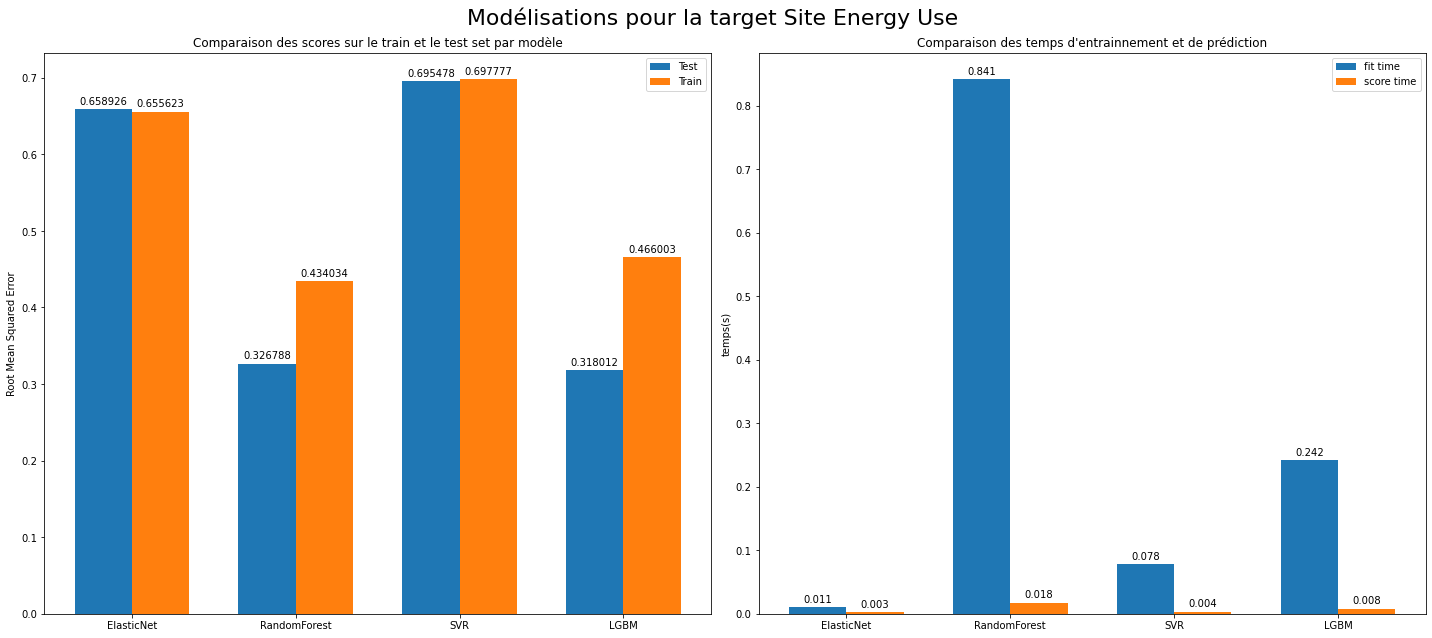

Durée d'exécution de affiche_modelisations: 0.600543737411499s


In [45]:
affiche_modelisations(res_tunning, "Site Energy Use")


# Features importance 

In [54]:

rf_site_optimal = rf_grid.best_estimator_

In [55]:
# Affichage des features importance
def affic_features_impotance_model(model,  X_test, name):
    
    feat_imp = model.feature_importances_
    df_featimp = pd.DataFrame(feat_imp, columns = {"Feature Importance"})
    df_featimp["Feature Name"] = X_test.columns
    df_featimp = df_featimp.sort_values(by="Feature Importance", ascending=True)
    display(df_featimp)
    
    # Affichage Features importance
    plt.figure(figsize=(10,7))
    #df_featimp.plot.bar(x= "Feature Importance", y = "Feature Name", title =f"Feature importance pour le modele {name} ")
    #plt.barh(X_test.columns, feat_imp)
    plt.barh(df_featimp["Feature Name"], df_featimp["Feature Importance"])
    plt.xlabel("Feature Importance")
    plt.title(f"Feature importance pour le modele {name} ")
    plt.show()

    return None

,Feature Importance,Feature Name
7,0.004876,SteamUse(kBtu)
16,0.005334,RateThirdLargestPropertyUseType
5,0.006502,ThirdLargestPropertyUseType
17,0.007722,NumberOfAllUseTypes
4,0.009723,SecondLargestPropertyUseType
11,0.012000,RateBuilding
10,0.013069,RateParking
15,0.014548,RateSecondLargestPropertyUseType
14,0.032466,RateLargestPropertyUseType
2,0.032603,Neighborhood


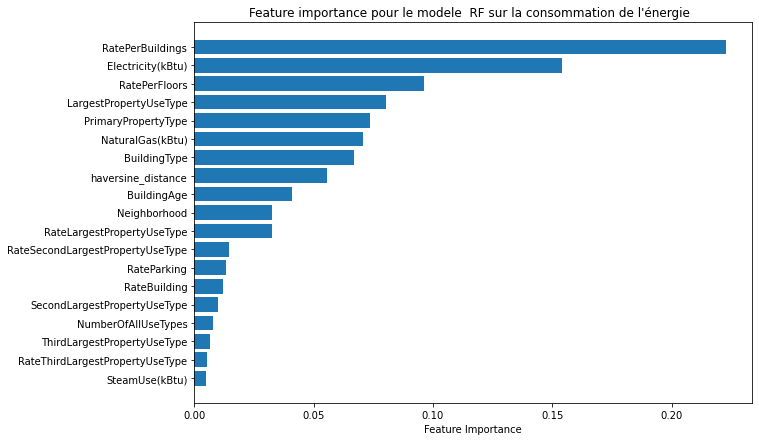

In [56]:
affic_features_impotance_model(rf_site_optimal, X_site_test, " RF sur la consommation de l'énergie ")

On note que :

 >l'électricité,

>le nombre total de type d'usage

> la surface du bâtiment,

>l'utilisation de vapeur

> le type de bâtiment type d'énergie,

n'influencent pas beaucoup (<0.05) sur la consommation totale de l'énergie.